# 02_analysis.ipynb
# Street Typology Classification and Similarity Search
# Seyma Berker | MSc Urban Spatial Science | UCL CASA 2026
# In partnership with Foster + Partners
# 
# Full analysis pipeline — run after 01_data_collection.ipynb:
#   - Feature engineering for all four cities
#   - K-means clustering to discover street typologies
#   - Visualisation of results including typology maps and charts
#   - Cross-city comparison
#   - Similarity search system for design precedent retrieval
#
# All figures are saved to /home/jovyan/work/outputs/

In [1]:
# Install and import all libraries needed for the analysis

import subprocess
import sys

packages = [
    'osmnx', 'geopandas', 'pandas', 'numpy',
    'matplotlib', 'scikit-learn', 'scipy',
    'networkx', 'contextily', 'seaborn'
]
for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip',
                          'install', package, '-q'])

import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import contextily as ctx
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from scipy.stats import entropy as shannon_entropy

warnings.filterwarnings('ignore')

print("All libraries ready.")
print(f"OSMnx version: {ox.__version__}")
print(f"GeoPandas version: {gpd.__version__}")

All libraries ready.
OSMnx version: 2.1.1
GeoPandas version: 1.1.1


In [2]:
# Feature columns and typology colours used throughout this notebook

FEATURE_COLS = [
    'length_m',               # Movement — segment length in metres
    'building_count_50m',     # Movement — building count within 50m
    'avg_building_area',      # Movement — average building footprint area
    'highway_rank',           # Movement — road class 1 to 6
    'sinuosity',              # Movement — path length / straight line distance
    'poi_count_50m',          # Place — amenity count within 50m
    'poi_diversity',          # Place — Shannon entropy across POI categories
    'food_drink_count',       # Place — cafes, restaurants, pubs within 50m
    'street_furniture_count', # Place — benches, fountains within 50m
    'avg_connectivity'        # Place — mean node degree at segment ends
]

TYPOLOGY_COLOURS = {
    'Active Commercial High Street':  '#BA7517',
    'Arterial Movement Corridor':     '#378ADD',
    'Local Mixed Street':             '#888780',
    'Institutional Large-Block Street': '#D85A30',
    'Winding Historic Lane':          '#1D9E75',
    'Pedestrian-Rich Street':         '#9B59B6',
    'Dense Local Street':             '#2C3E50',
    'Active Boulevard':               '#8E44AD',
    'Winding Connector Lane':         '#27AE60',
}

print(f"Features defined: {len(FEATURE_COLS)}")
print(f"Typologies defined: {len(TYPOLOGY_COLOURS)}")

Features defined: 10
Typologies defined: 9


In [3]:
# Feature engineering pipeline function
# Calculates all 10 spatial features for each street segment
# Same function applied to all four cities for consistency

def run_pipeline(city_name, streets_file, buildings_file, pois_file, epsg):

    print(f"\nProcessing {city_name}...")

    edges = gpd.read_file(streets_file)
    buildings = gpd.read_file(buildings_file)
    pois = gpd.read_file(pois_file)
    print(f"  Loaded: {len(edges)} streets, {len(buildings)} buildings, {len(pois)} POIs")

    edges_proj = edges.to_crs(epsg=epsg)
    buildings_proj = buildings.to_crs(epsg=epsg)
    pois_proj = pois.to_crs(epsg=epsg)

    # 50m buffer around each segment — captures pedestrian-scale environment
    edges_buffered = edges_proj.copy()
    edges_buffered['geometry'] = edges_proj.geometry.buffer(50)

    # Length
    edges_proj['length_m'] = edges_proj.geometry.length

    # Building count within 50m
    joined_b = gpd.sjoin(edges_buffered[['geometry']],
                         buildings_proj[['geometry']],
                         how='left', predicate='intersects')
    edges_proj['building_count_50m'] = joined_b.groupby(
        joined_b.index).size().reindex(edges_proj.index, fill_value=0)

    # Average building area within 50m
    buildings_proj['area'] = buildings_proj.geometry.area
    joined_ba = gpd.sjoin(edges_buffered[['geometry']],
                          buildings_proj[['geometry', 'area']],
                          how='left', predicate='intersects')
    edges_proj['avg_building_area'] = joined_ba.groupby(
        joined_ba.index)['area'].mean().reindex(edges_proj.index, fill_value=0)

    # POI count within 50m
    joined_p = gpd.sjoin(edges_buffered[['geometry']],
                         pois_proj[['geometry']],
                         how='left', predicate='intersects')
    edges_proj['poi_count_50m'] = joined_p.groupby(
        joined_p.index).size().reindex(edges_proj.index, fill_value=0)

    # Highway rank — OSM road class converted to ordinal scale 1 to 6
    def clean_highway(val):
        if isinstance(val, list):
            return val[0]
        return val

    highway_map = {
        'trunk': 6, 'primary': 5, 'primary_link': 5,
        'secondary': 4, 'secondary_link': 4,
        'tertiary': 3, 'tertiary_link': 3,
        'residential': 2, 'living_street': 2, 'unclassified': 1
    }
    edges_proj['highway_clean'] = edges_proj['highway'].apply(clean_highway)
    edges_proj['highway_rank'] = edges_proj['highway_clean'].map(
        highway_map).fillna(1)

    # Sinuosity — 1.0 is straight, higher values indicate winding streets
    def calculate_sinuosity(geom):
        if geom.length == 0:
            return 1.0
        start = geom.coords[0]
        end = geom.coords[-1]
        straight = ((end[0]-start[0])**2 + (end[1]-start[1])**2)**0.5
        if straight == 0:
            return 1.0
        return geom.length / straight

    edges_proj['sinuosity'] = edges_proj.geometry.apply(calculate_sinuosity)

    # POI categories following Gehl (2010)
    food_drink_tags = ['restaurant', 'fast_food', 'cafe', 'pub', 'bar']
    furniture_tags = ['bench', 'fountain', 'clock', 'telephone', 'post_box']

    def categorise_poi(row):
        amenity = str(row.get('amenity', ''))
        shop = str(row.get('shop', ''))
        if amenity in food_drink_tags: return 'food_drink'
        elif amenity in ['bicycle_parking', 'bicycle_rental',
                         'motorcycle_parking', 'parking']: return 'transport'
        elif amenity in ['bank', 'atm']: return 'finance'
        elif amenity in ['place_of_worship', 'doctors',
                         'dentist', 'pharmacy']: return 'civic'
        elif amenity in furniture_tags: return 'street_furniture'
        elif shop not in ['nan', '']: return 'retail'
        else: return 'other'

    pois_proj['category'] = pois_proj.apply(categorise_poi, axis=1)

    # POI diversity — Shannon entropy across 6 categories (Jacobs, 1993)
    joined_cats = gpd.sjoin(edges_buffered[['geometry']],
                            pois_proj[['geometry', 'category']],
                            how='left', predicate='intersects')

    def calculate_entropy(group):
        return shannon_entropy(group['category'].value_counts())

    poi_entropy = joined_cats.groupby(joined_cats.index).apply(calculate_entropy)
    edges_proj['poi_diversity'] = poi_entropy.reindex(
        edges_proj.index, fill_value=0)

    # Food and drink count — proxy for active frontage (Gehl, 2010)
    food_pois = pois_proj[pois_proj['category'] == 'food_drink']
    joined_food = gpd.sjoin(edges_buffered[['geometry']],
                            food_pois[['geometry']],
                            how='left', predicate='intersects')
    edges_proj['food_drink_count'] = joined_food.groupby(
        joined_food.index).size().reindex(edges_proj.index, fill_value=0)

    # Street furniture count — pedestrian amenity indicator (Gehl, 2010)
    furn_pois = pois_proj[pois_proj['category'] == 'street_furniture']
    joined_furn = gpd.sjoin(edges_buffered[['geometry']],
                            furn_pois[['geometry']],
                            how='left', predicate='intersects')
    edges_proj['street_furniture_count'] = joined_furn.groupby(
        joined_furn.index).size().reindex(edges_proj.index, fill_value=0)

    # Average node degree connectivity
    edges_reset = edges_proj.reset_index()
    if 'u' in edges_reset.columns and 'v' in edges_reset.columns:
        all_nodes = pd.concat([edges_reset['u'], edges_reset['v']])
        degree_dict = all_nodes.value_counts().to_dict()
        edges_reset['degree_u'] = edges_reset['u'].map(degree_dict).fillna(2)
        edges_reset['degree_v'] = edges_reset['v'].map(degree_dict).fillna(2)
        edges_reset['avg_connectivity'] = (
            edges_reset['degree_u'] + edges_reset['degree_v']) / 2
        edges_proj = edges_reset.set_index(['u', 'v', 'key'])
    else:
        edges_proj['avg_connectivity'] = 4.0

    edges_proj['city'] = city_name
    print(f"  Complete. Missing values: {edges_proj[FEATURE_COLS].isnull().sum().sum()}")

    return edges_proj

print("Pipeline function ready.")

Pipeline function ready.


In [4]:
# Run feature engineering pipeline for all four cities
# London uses EPSG 27700 (British National Grid)
# Other cities use EPSG 3857 (Web Mercator) for global compatibility

london = run_pipeline(
    city_name="London",
    streets_file="/home/jovyan/work/data/london_streets.gpkg",
    buildings_file="/home/jovyan/work/data/london_buildings.gpkg",
    pois_file="/home/jovyan/work/data/london_pois.gpkg",
    epsg=27700
)

barcelona = run_pipeline(
    city_name="Barcelona",
    streets_file="/home/jovyan/work/data/barcelona_streets.gpkg",
    buildings_file="/home/jovyan/work/data/barcelona_buildings.gpkg",
    pois_file="/home/jovyan/work/data/barcelona_pois.gpkg",
    epsg=3857
)

singapore = run_pipeline(
    city_name="Singapore",
    streets_file="/home/jovyan/work/data/singapore_streets.gpkg",
    buildings_file="/home/jovyan/work/data/singapore_buildings.gpkg",
    pois_file="/home/jovyan/work/data/singapore_pois.gpkg",
    epsg=3857
)

tokyo = run_pipeline(
    city_name="Tokyo",
    streets_file="/home/jovyan/work/data/tokyo_streets.gpkg",
    buildings_file="/home/jovyan/work/data/tokyo_buildings.gpkg",
    pois_file="/home/jovyan/work/data/tokyo_pois.gpkg",
    epsg=3857
)

print(f"\nAll four cities processed.")
print(f"London: {len(london)} | Barcelona: {len(barcelona)} | Singapore: {len(singapore)} | Tokyo: {len(tokyo)}")
print(f"Total: {len(london)+len(barcelona)+len(singapore)+len(tokyo)} segments")


Processing London...
  Loaded: 1382 streets, 2104 buildings, 3388 POIs
  Complete. Missing values: 0

Processing Barcelona...
  Loaded: 1503 streets, 8253 buildings, 8956 POIs
  Complete. Missing values: 20

Processing Singapore...
  Loaded: 548 streets, 2987 buildings, 643 POIs
  Complete. Missing values: 19

Processing Tokyo...
  Loaded: 1577 streets, 9580 buildings, 702 POIs
  Complete. Missing values: 0

All four cities processed.
London: 1382 | Barcelona: 1503 | Singapore: 548 | Tokyo: 1577
Total: 5010 segments


In [5]:
# Check and handle missing values before clustering
# Missing avg_building_area values mean no buildings within 50m — filled with 0

for city_name, gdf in [('London', london), ('Barcelona', barcelona),
                        ('Singapore', singapore), ('Tokyo', tokyo)]:
    missing = gdf[FEATURE_COLS].isnull().sum()
    missing_cols = missing[missing > 0]
    if len(missing_cols) > 0:
        print(f"{city_name} missing values:")
        print(missing_cols)
    else:
        print(f"{city_name}: no missing values")

for df in [london, barcelona, singapore, tokyo]:
    df[FEATURE_COLS] = df[FEATURE_COLS].fillna(0)

print("\nAll features ready for clustering.")

London: no missing values
Barcelona missing values:
avg_building_area    20
dtype: int64
Singapore missing values:
avg_building_area    19
dtype: int64
Tokyo: no missing values

All features ready for clustering.


In [6]:
# Confirm all missing values are now filled
total_missing = sum(gdf[FEATURE_COLS].isnull().sum().sum() 
                   for gdf in [london, barcelona, singapore, tokyo])
print(f"Total missing values after filling: {total_missing}")
print("\nAll features ready for clustering.")

Total missing values after filling: 0

All features ready for clustering.


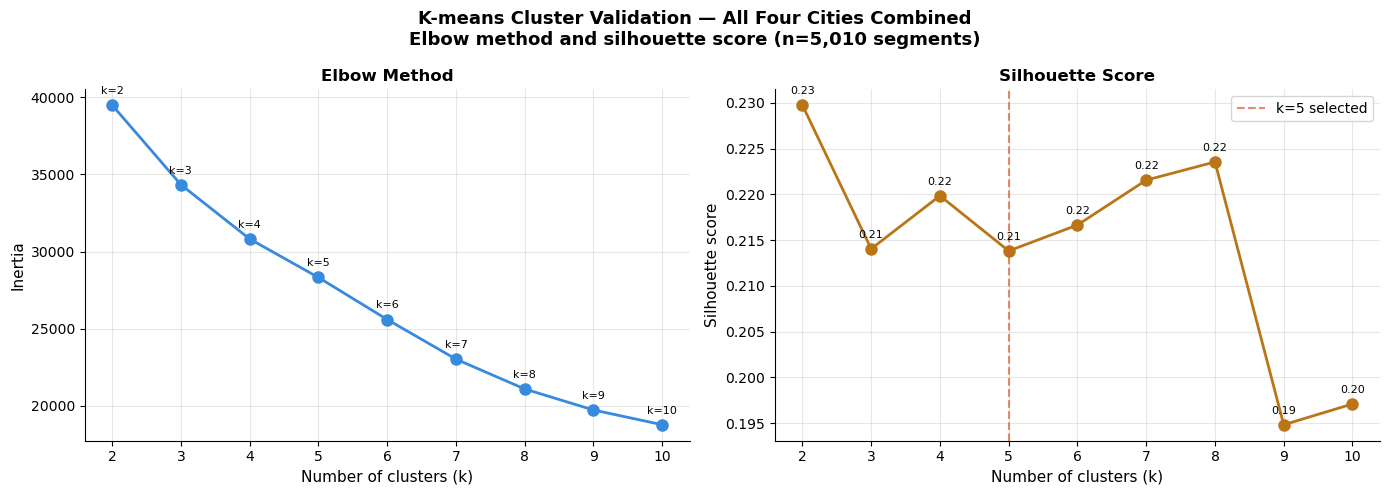

Silhouette scores: [0.23, 0.214, 0.22, 0.214, 0.217, 0.222, 0.224, 0.195, 0.197]
Best k by silhouette: 2
Selected k=5 based on elbow method and typological interpretability
Figure 4.2 saved.


In [9]:
# Elbow method and silhouette score to select optimal k
# Applied to combined dataset of all four cities
# to justify k=5 as globally appropriate

# Combine all four cities for validation
all_cities_combined = pd.concat([
    london.reset_index()[FEATURE_COLS],
    barcelona.reset_index()[FEATURE_COLS],
    singapore.reset_index()[FEATURE_COLS],
    tokyo.reset_index()[FEATURE_COLS]
], ignore_index=True).fillna(0)

X_all = all_cities_combined.values
scaler_elbow = StandardScaler()
X_all_scaled = scaler_elbow.fit_transform(X_all)

inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_all_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_all_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia, 'o-', color='#378ADD', linewidth=2, markersize=8)
for k, val in zip(k_range, inertia):
    axes[0].annotate(f'k={k}', (k, val),
                    textcoords="offset points", xytext=(0, 8),
                    ha='center', fontsize=8)
axes[0].set_xlabel('Number of clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia', fontsize=11)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].plot(k_range, silhouette_scores, 'o-',
            color='#BA7517', linewidth=2, markersize=8)
axes[1].axvline(x=5, color='#D85A30', linestyle='--',
               alpha=0.7, label='k=5 selected')
for k, val in zip(k_range, silhouette_scores):
    axes[1].annotate(f'{val:.2f}', (k, val),
                    textcoords="offset points", xytext=(0, 8),
                    ha='center', fontsize=8)
axes[1].set_xlabel('Number of clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette score', fontsize=11)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle(
    'K-means Cluster Validation — All Four Cities Combined\n'
    f'Elbow method and silhouette score (n=5,010 segments)',
    fontsize=13, fontweight='bold'
)

plt.tight_layout()
plt.savefig("/home/jovyan/work/outputs/cluster_validation.png",
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print(f"Silhouette scores: {[round(s,3) for s in silhouette_scores]}")
print(f"Best k by silhouette: {list(k_range)[silhouette_scores.index(max(silhouette_scores))]}")
print(f"Selected k=5 based on elbow method and typological interpretability")
print("Figure 4.2 saved.")

In [10]:
# K-means clustering with k=5 applied to all four cities
# k=5 selected by elbow method — silhouette peaks at k=2 but
# two clusters produce insufficient typological variety for
# urban design application (Jang et al., 2024)

def cluster_city(gdf, city_name):
    X = gdf[FEATURE_COLS].fillna(0).values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
    gdf = gdf.copy()
    gdf['cluster'] = kmeans.fit_predict(X_scaled)
    print(f"\n{city_name} cluster sizes:")
    print(gdf['cluster'].value_counts().sort_index())
    return gdf, scaler, kmeans

london_clustered, lon_scaler, lon_kmeans = cluster_city(
    london.reset_index(), "London")
barcelona_clustered, bcn_scaler, bcn_kmeans = cluster_city(
    barcelona.reset_index(), "Barcelona")
singapore_clustered, sgp_scaler, sgp_kmeans = cluster_city(
    singapore.reset_index(), "Singapore")
tokyo_clustered, tky_scaler, tky_kmeans = cluster_city(
    tokyo.reset_index(), "Tokyo")

print("\nClustering complete.")


London cluster sizes:
cluster
0    216
1    346
2    712
3      9
4     99
Name: count, dtype: int64

Barcelona cluster sizes:
cluster
0     74
1    126
2    701
3    588
4     14
Name: count, dtype: int64

Singapore cluster sizes:
cluster
0    179
1     92
2    264
3     10
4      3
Name: count, dtype: int64

Tokyo cluster sizes:
cluster
0     33
1    964
2     10
3    531
4     39
Name: count, dtype: int64

Clustering complete.


In [11]:
# Assign typology names based on cluster feature profiles
# Names follow the TfL Street Family framework (Transport for London, 2017)

london_names = {
    0: 'Active Commercial High Street',
    1: 'Institutional Large-Block Street',
    2: 'Local Mixed Street',
    3: 'Winding Historic Lane',
    4: 'Pedestrian-Rich Street'
}

barcelona_names = {
    0: 'Institutional Large-Block Street',
    1: 'Active Commercial High Street',
    2: 'Local Mixed Street',
    3: 'Arterial Movement Corridor',
    4: 'Active Boulevard'
}

singapore_names = {
    0: 'Arterial Movement Corridor',
    1: 'Active Commercial High Street',
    2: 'Local Mixed Street',
    3: 'Winding Connector Lane',
    4: 'Pedestrian-Rich Street'
}

tokyo_names = {
    0: 'Arterial Movement Corridor',
    1: 'Dense Local Street',
    2: 'Winding Historic Lane',
    3: 'Local Mixed Street',
    4: 'Active Commercial High Street'
}

london_clustered['typology'] = london_clustered['cluster'].map(london_names)
barcelona_clustered['typology'] = barcelona_clustered['cluster'].map(barcelona_names)
singapore_clustered['typology'] = singapore_clustered['cluster'].map(singapore_names)
tokyo_clustered['typology'] = tokyo_clustered['cluster'].map(tokyo_names)

print("London:"); print(london_clustered['typology'].value_counts())
print("\nBarcelona:"); print(barcelona_clustered['typology'].value_counts())
print("\nSingapore:"); print(singapore_clustered['typology'].value_counts())
print("\nTokyo:"); print(tokyo_clustered['typology'].value_counts())

London:
typology
Local Mixed Street                  712
Institutional Large-Block Street    346
Active Commercial High Street       216
Pedestrian-Rich Street               99
Winding Historic Lane                 9
Name: count, dtype: int64

Barcelona:
typology
Local Mixed Street                  701
Arterial Movement Corridor          588
Active Commercial High Street       126
Institutional Large-Block Street     74
Active Boulevard                     14
Name: count, dtype: int64

Singapore:
typology
Local Mixed Street               264
Arterial Movement Corridor       179
Active Commercial High Street     92
Winding Connector Lane            10
Pedestrian-Rich Street             3
Name: count, dtype: int64

Tokyo:
typology
Dense Local Street               964
Local Mixed Street               531
Active Commercial High Street     39
Arterial Movement Corridor        33
Winding Historic Lane             10
Name: count, dtype: int64


In [12]:
# Save clustered results for all four cities

london_clustered.to_file(
    "/home/jovyan/work/data/london_final.gpkg", driver="GPKG")
barcelona_clustered.to_file(
    "/home/jovyan/work/data/barcelona_final.gpkg", driver="GPKG")
singapore_clustered.to_file(
    "/home/jovyan/work/data/singapore_final.gpkg", driver="GPKG")
tokyo_clustered.to_file(
    "/home/jovyan/work/data/tokyo_final.gpkg", driver="GPKG")

print("All results saved.")
print(f"London:    {len(london_clustered)} segments, {london_clustered['typology'].nunique()} typologies")
print(f"Barcelona: {len(barcelona_clustered)} segments, {barcelona_clustered['typology'].nunique()} typologies")
print(f"Singapore: {len(singapore_clustered)} segments, {singapore_clustered['typology'].nunique()} typologies")
print(f"Tokyo:     {len(tokyo_clustered)} segments, {tokyo_clustered['typology'].nunique()} typologies")
print(f"Total:     {len(london_clustered)+len(barcelona_clustered)+len(singapore_clustered)+len(tokyo_clustered)} segments")

All results saved.
London:    1382 segments, 5 typologies
Barcelona: 1503 segments, 5 typologies
Singapore: 548 segments, 5 typologies
Tokyo:     1577 segments, 5 typologies
Total:     5010 segments


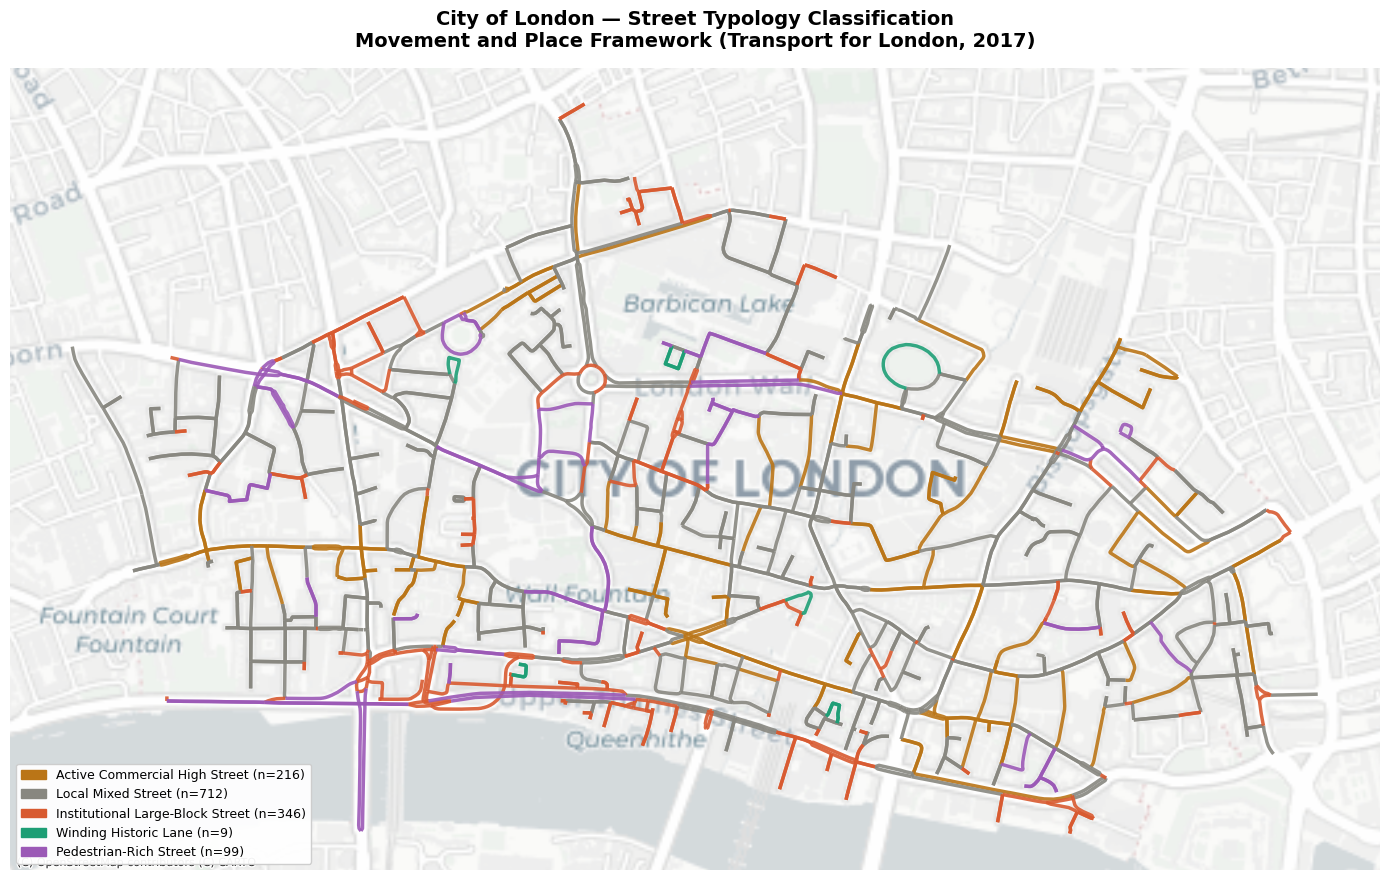

City of London map saved.


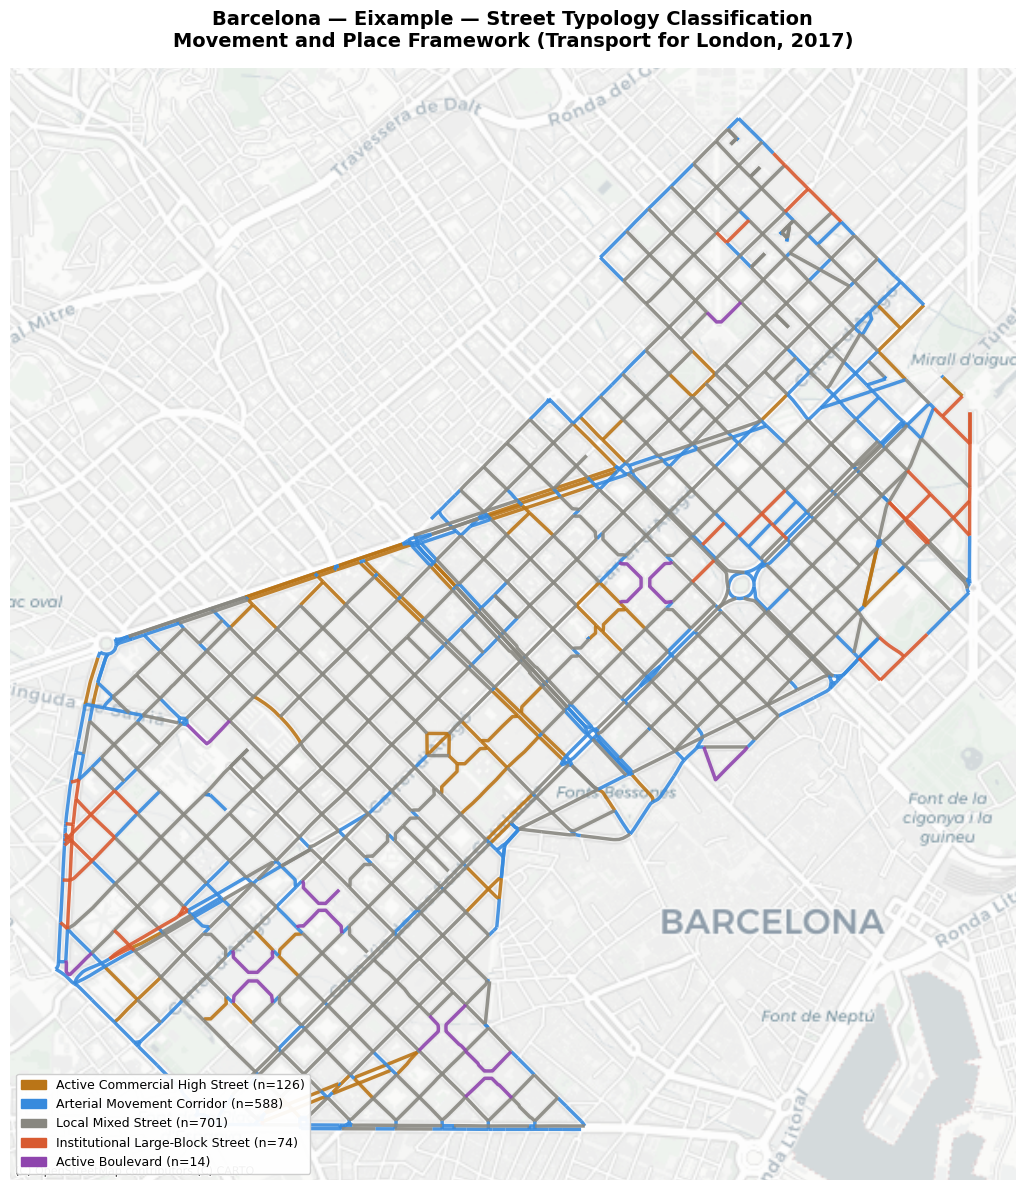

Barcelona — Eixample map saved.


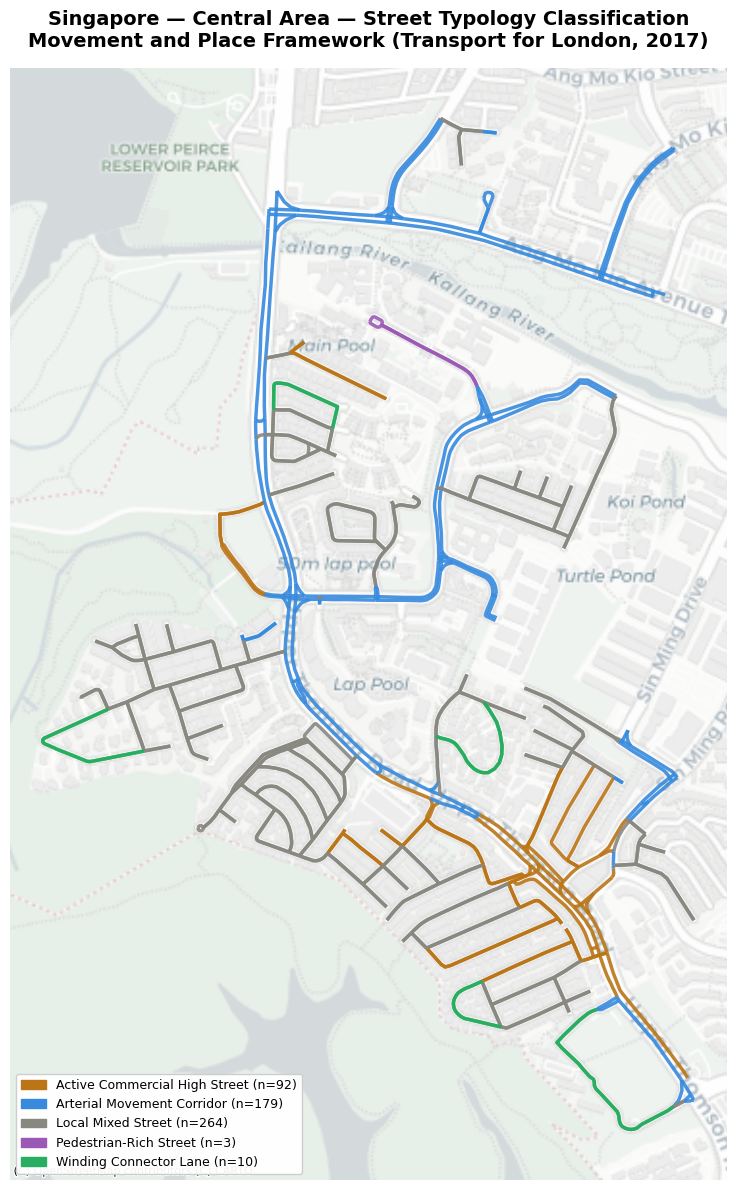

Singapore — Central Area map saved.


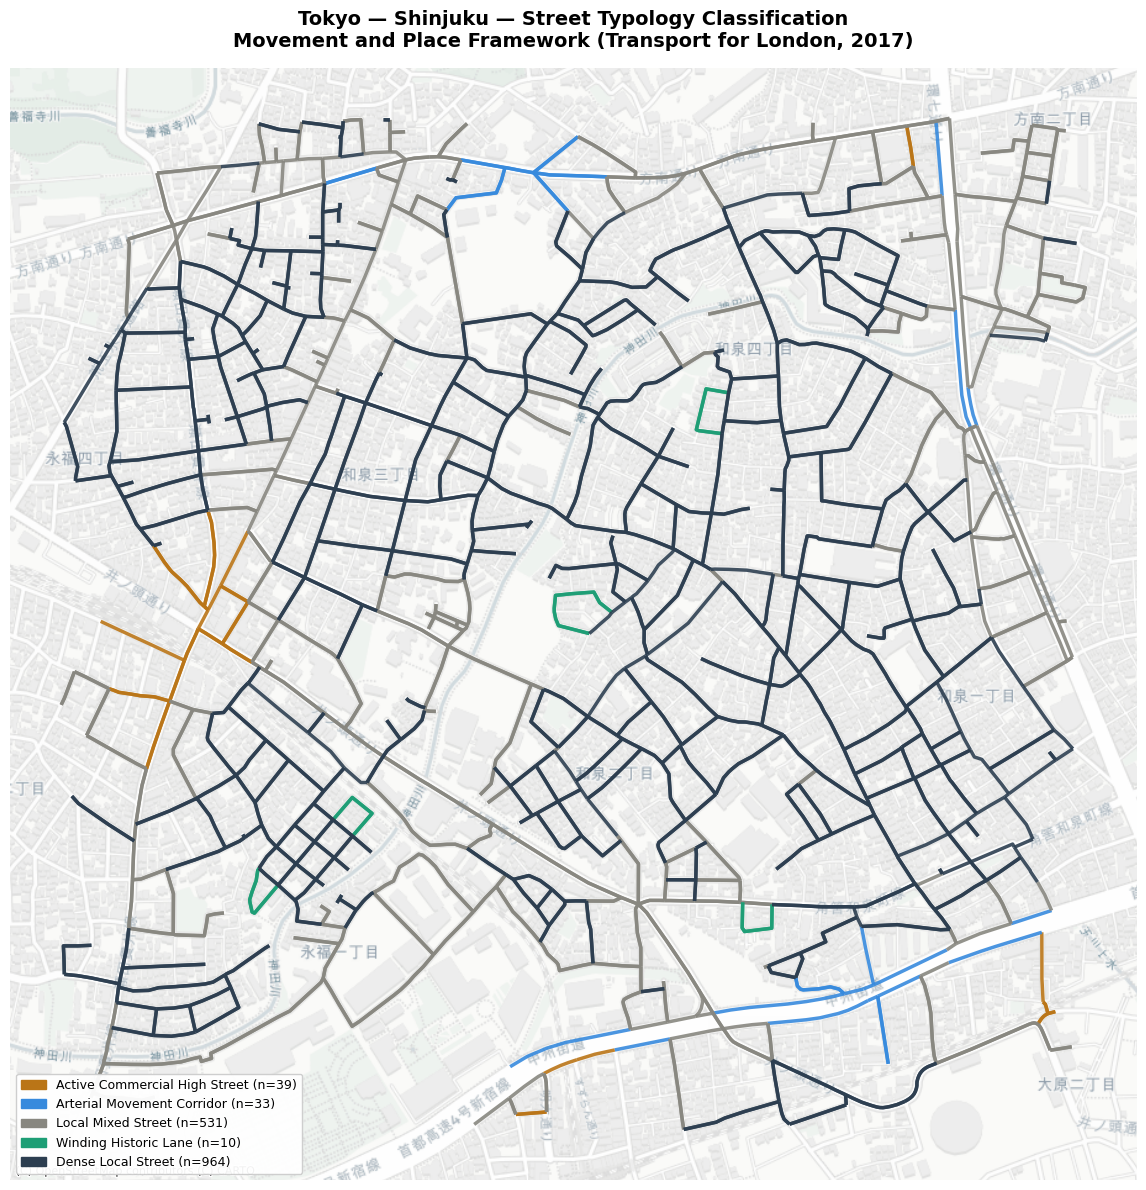

Tokyo — Shinjuku map saved.


In [13]:
# Generate typology maps for all four cities
# Maps use CartoDB Positron basemap for context
# Figures 5.1 to 5.4 in the dissertation

def plot_typology_map(gdf, city_name, filename):
    gdf_web = gdf.to_crs(epsg=3857)
    fig, ax = plt.subplots(figsize=(14, 12))
    
    plotted = []
    for typology, colour in TYPOLOGY_COLOURS.items():
        subset = gdf_web[gdf_web['typology'] == typology]
        if len(subset) > 0:
            subset.plot(ax=ax, color=colour, linewidth=2.5,
                       alpha=0.9, zorder=2)
            plotted.append(mpatches.Patch(
                color=colour, label=f'{typology} (n={len(subset)})'))
    
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom='auto')
    ax.set_title(
        f"{city_name} — Street Typology Classification\n"
        f"Movement and Place Framework (Transport for London, 2017)",
        fontsize=14, fontweight='bold', pad=15)
    ax.set_axis_off()
    ax.legend(handles=plotted, loc='lower left',
              fontsize=9, framealpha=0.95, edgecolor='#CCCCCC')
    
    plt.tight_layout()
    plt.savefig(f"/home/jovyan/work/outputs/{filename}",
                dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"{city_name} map saved.")

# London — merge typology back to original geometry
london_geo = gpd.read_file("/home/jovyan/work/data/london_streets.gpkg")
london_geo = london_geo.merge(
    london_clustered[['u', 'v', 'key', 'typology']],
    on=['u', 'v', 'key'], how='left')

plot_typology_map(london_geo, 'City of London',
                 'london_typology_basemap.png')
plot_typology_map(barcelona_clustered, 'Barcelona — Eixample',
                 'barcelona_typology_basemap.png')
plot_typology_map(singapore_clustered, 'Singapore — Central Area',
                 'singapore_typology_basemap.png')
plot_typology_map(tokyo_clustered, 'Tokyo — Shinjuku',
                 'tokyo_typology_basemap.png')

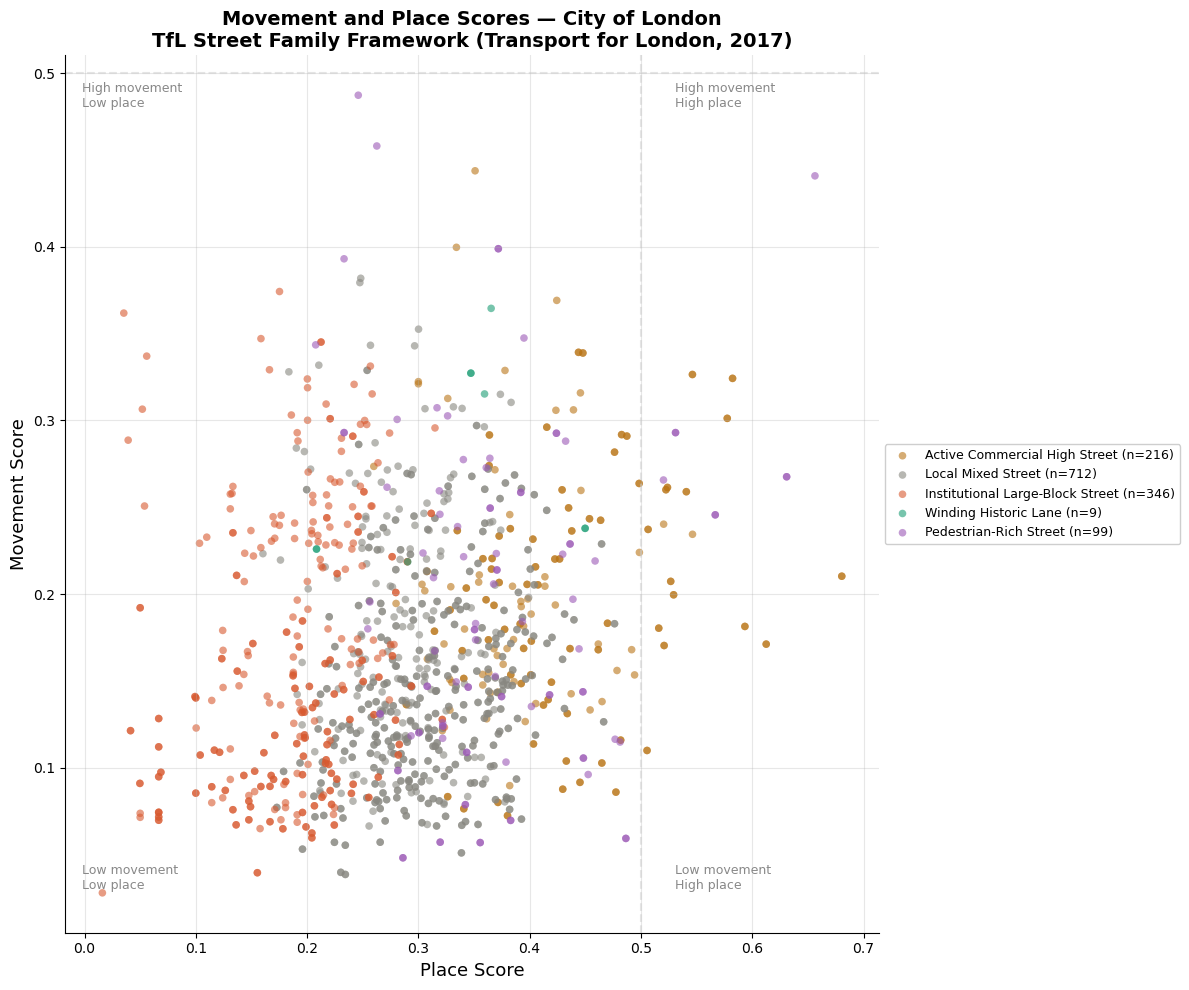

Figure 5.5 saved.


In [14]:
# Movement vs place scatter plot for London
# Positions each street segment in the TfL two-dimensional space
# Figure 5.5 in the dissertation

# Calculate movement and place scores for London
movement_features = ['length_m', 'building_count_50m', 'avg_building_area',
                     'highway_rank', 'sinuosity']
place_features = ['poi_count_50m', 'poi_diversity', 'food_drink_count',
                  'street_furniture_count', 'avg_connectivity']

london_plot = london_clustered.copy()

# Normalise and calculate composite scores
scaler_mp = MinMaxScaler()
london_plot[FEATURE_COLS] = scaler_mp.fit_transform(
    london_plot[FEATURE_COLS].fillna(0))

london_plot['movement_score'] = london_plot[movement_features].mean(axis=1)
london_plot['place_score'] = london_plot[place_features].mean(axis=1)

fig, ax = plt.subplots(figsize=(12, 10))

for typology, colour in TYPOLOGY_COLOURS.items():
    subset = london_plot[london_plot['typology'] == typology]
    if len(subset) > 0:
        ax.scatter(subset['place_score'], subset['movement_score'],
                  c=colour, label=f'{typology} (n={len(subset)})',
                  alpha=0.6, s=30, edgecolors='none')

ax.set_xlabel('Place Score', fontsize=13)
ax.set_ylabel('Movement Score', fontsize=13)
ax.set_title('Movement and Place Scores — City of London\n'
             'TfL Street Family Framework (Transport for London, 2017)',
             fontsize=14, fontweight='bold')

# Add quadrant labels
ax.axhline(y=0.5, color='#CCCCCC', linestyle='--', alpha=0.5)
ax.axvline(x=0.5, color='#CCCCCC', linestyle='--', alpha=0.5)
ax.text(0.02, 0.97, 'High movement\nLow place',
        transform=ax.transAxes, fontsize=9, color='#888888',
        verticalalignment='top')
ax.text(0.75, 0.97, 'High movement\nHigh place',
        transform=ax.transAxes, fontsize=9, color='#888888',
        verticalalignment='top')
ax.text(0.02, 0.05, 'Low movement\nLow place',
        transform=ax.transAxes, fontsize=9, color='#888888')
ax.text(0.75, 0.05, 'Low movement\nHigh place',
        transform=ax.transAxes, fontsize=9, color='#888888')

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5),
          fontsize=9, framealpha=0.95)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("/home/jovyan/work/outputs/movement_place_plot.png",
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 5.5 saved.")

In [15]:
# Cross-city typology distribution
# Table 5.2 and Figure 5.6 in the dissertation

summary = []
city_dfs = {
    'London': london_clustered,
    'Barcelona': barcelona_clustered,
    'Singapore': singapore_clustered,
    'Tokyo': tokyo_clustered
}

for city, df in city_dfs.items():
    total = len(df)
    for typology, count in df['typology'].value_counts().items():
        summary.append({
            'City': city,
            'Typology': typology,
            'Count': count,
            'Percentage': round(count / total * 100, 1)
        })

summary_df = pd.DataFrame(summary)
pivot = summary_df.pivot_table(
    index='Typology', columns='City',
    values='Percentage', aggfunc='sum'
).fillna(0).round(1)

cities_order = ['London', 'Barcelona', 'Singapore', 'Tokyo']
pivot = pivot[cities_order]

print("Cross-city typology distribution (%):")
print(pivot)

pivot.to_csv("/home/jovyan/work/data/cross_city_comparison_final_v2.csv")
print("\nTable 5.2 saved.")

Cross-city typology distribution (%):
City                              London  Barcelona  Singapore  Tokyo
Typology                                                             
Active Boulevard                     0.0        0.9        0.0    0.0
Active Commercial High Street       15.6        8.4       16.8    2.5
Arterial Movement Corridor           0.0       39.1       32.7    2.1
Dense Local Street                   0.0        0.0        0.0   61.1
Institutional Large-Block Street    25.0        4.9        0.0    0.0
Local Mixed Street                  51.5       46.6       48.2   33.7
Pedestrian-Rich Street               7.2        0.0        0.5    0.0
Winding Connector Lane               0.0        0.0        1.8    0.0
Winding Historic Lane                0.7        0.0        0.0    0.6

Table 5.2 saved.


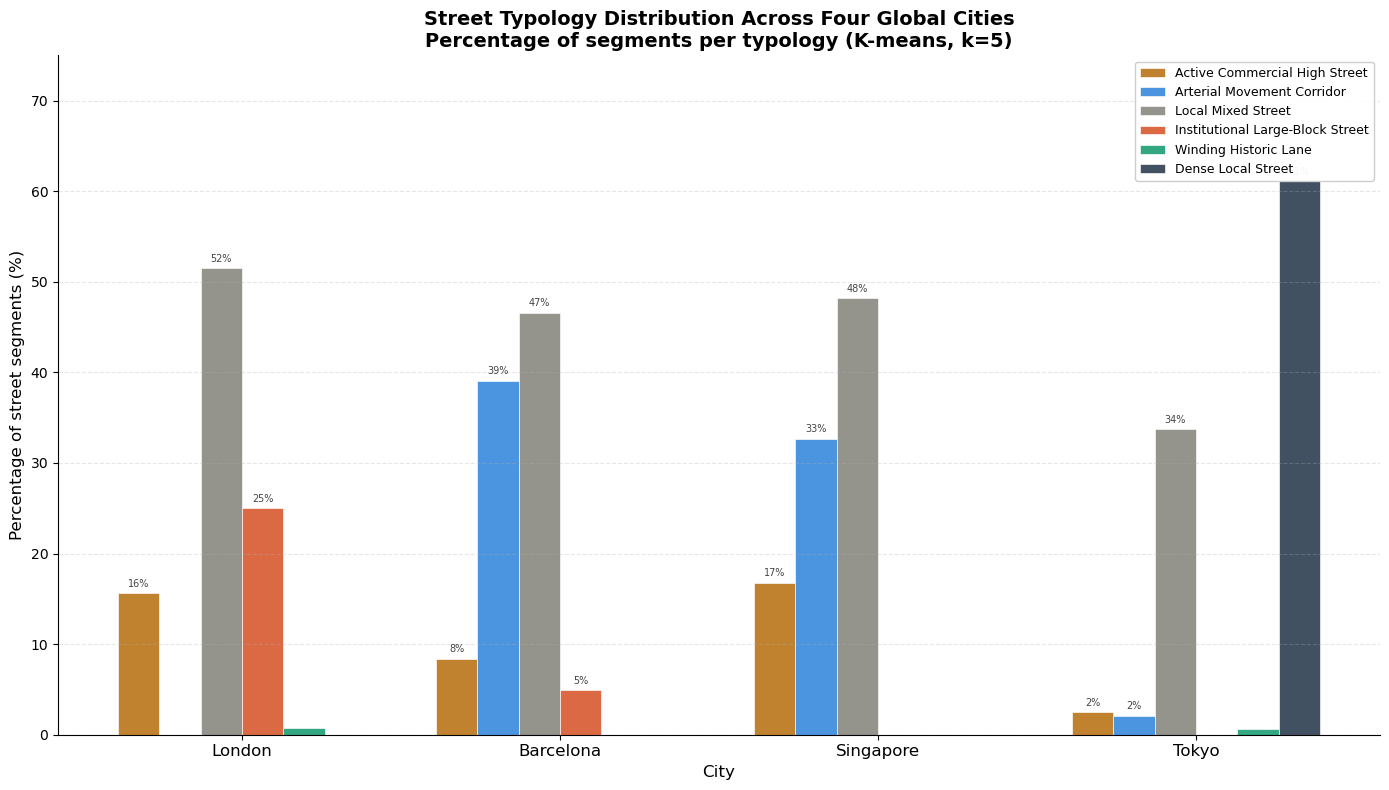

Figure 5.6 saved.


In [16]:
# Cross-city typology bar chart — Figure 5.6

main_typologies = [
    'Active Commercial High Street',
    'Arterial Movement Corridor',
    'Local Mixed Street',
    'Institutional Large-Block Street',
    'Winding Historic Lane',
    'Dense Local Street'
]

pivot_main = pivot.loc[pivot.index.isin(main_typologies)].fillna(0)

fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(cities_order))
width = 0.13
multiplier = 0

for typology in main_typologies:
    if typology in pivot_main.index:
        values = pivot_main.loc[typology, cities_order].values
        offset = width * multiplier
        bars = ax.bar(x + offset, values, width,
                     label=typology,
                     color=TYPOLOGY_COLOURS.get(typology, '#888780'),
                     alpha=0.9, edgecolor='white', linewidth=0.5)
        for bar, val in zip(bars, values):
            if val > 2:
                ax.text(bar.get_x() + bar.get_width() / 2,
                       bar.get_height() + 0.5,
                       f'{val:.0f}%', ha='center', va='bottom',
                       fontsize=7, color='#444444')
        multiplier += 1

ax.set_xlabel('City', fontsize=12)
ax.set_ylabel('Percentage of street segments (%)', fontsize=12)
ax.set_title(
    'Street Typology Distribution Across Four Global Cities\n'
    'Percentage of segments per typology (K-means, k=5)',
    fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(cities_order, fontsize=12)
ax.legend(loc='upper right', fontsize=9,
          framealpha=0.95, edgecolor='#CCCCCC')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, 75)

plt.tight_layout()
plt.savefig("/home/jovyan/work/outputs/cross_city_bar_chart.png",
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 5.6 saved.")

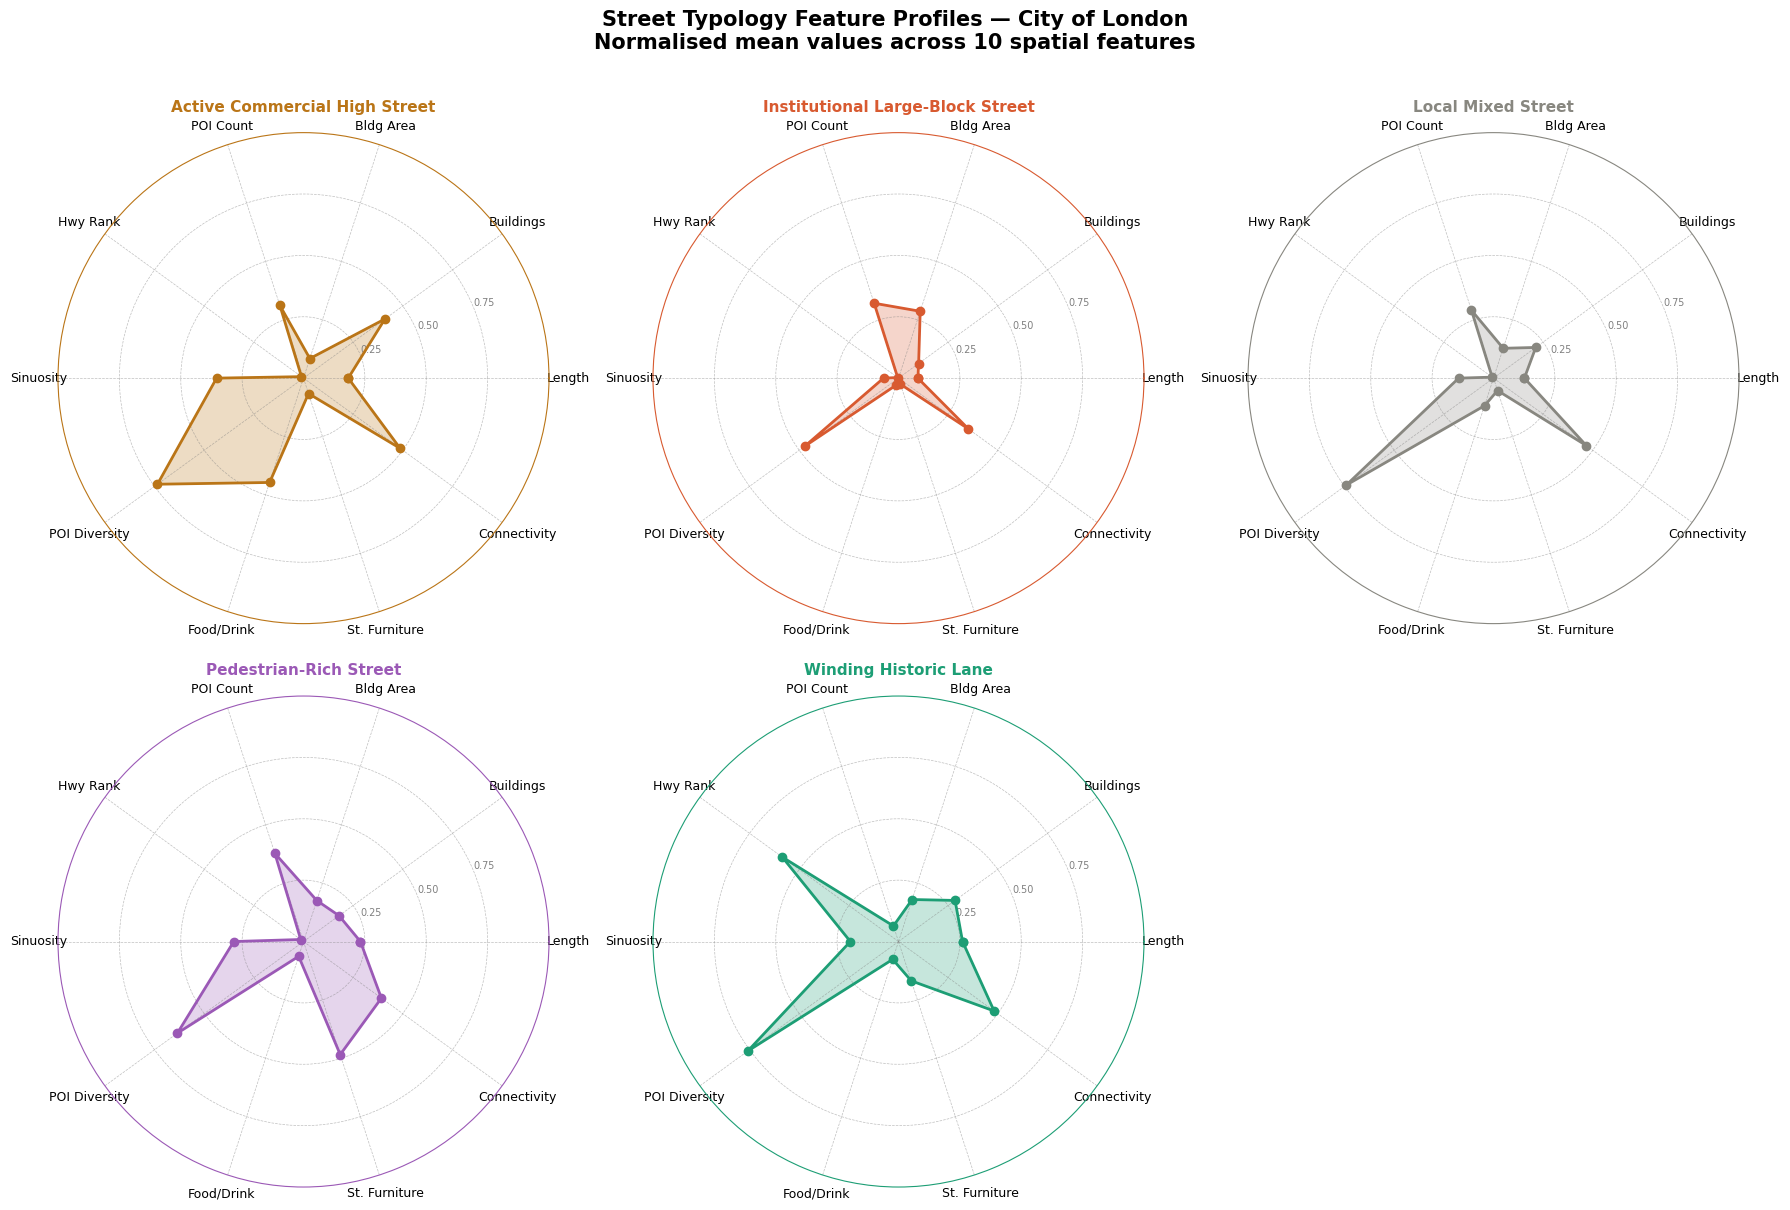

Figure 5.7 saved.


In [17]:
# Radar charts showing feature profiles per typology
# One chart per typology for London — Figure 5.7
# Cross-city comparison for key typologies — Figure 5.8

from sklearn.preprocessing import MinMaxScaler

feature_labels_radar = [
    'Length', 'Buildings', 'Bldg Area',
    'POI Count', 'Hwy Rank', 'Sinuosity',
    'POI Diversity', 'Food/Drink',
    'St. Furniture', 'Connectivity'
]

N = len(FEATURE_COLS)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# London radar charts
scaler_radar = MinMaxScaler()
london_norm = london_clustered.copy()
london_norm[FEATURE_COLS] = scaler_radar.fit_transform(
    london_norm[FEATURE_COLS].fillna(0))

profiles_london = london_norm.groupby('typology')[FEATURE_COLS].mean()
typologies_london = list(profiles_london.index)

fig, axes = plt.subplots(2, 3, figsize=(18, 12),
                         subplot_kw=dict(polar=True))
axes = axes.flatten()

for idx, typology in enumerate(typologies_london):
    ax = axes[idx]
    values = profiles_london.loc[typology].values.tolist()
    values += values[:1]
    colour = TYPOLOGY_COLOURS.get(typology, '#888780')
    ax.plot(angles, values, 'o-', linewidth=2, color=colour)
    ax.fill(angles, values, alpha=0.25, color=colour)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feature_labels_radar, size=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['0.25', '0.50', '0.75'], size=7, color='grey')
    ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_title(typology, size=11, fontweight='bold', color=colour, pad=15)
    ax.spines['polar'].set_color(colour)

for i in range(len(typologies_london), 6):
    axes[i].set_visible(False)

fig.suptitle('Street Typology Feature Profiles — City of London\n'
             'Normalised mean values across 10 spatial features',
             fontsize=15, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig("/home/jovyan/work/outputs/radar_charts.png",
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 5.7 saved.")

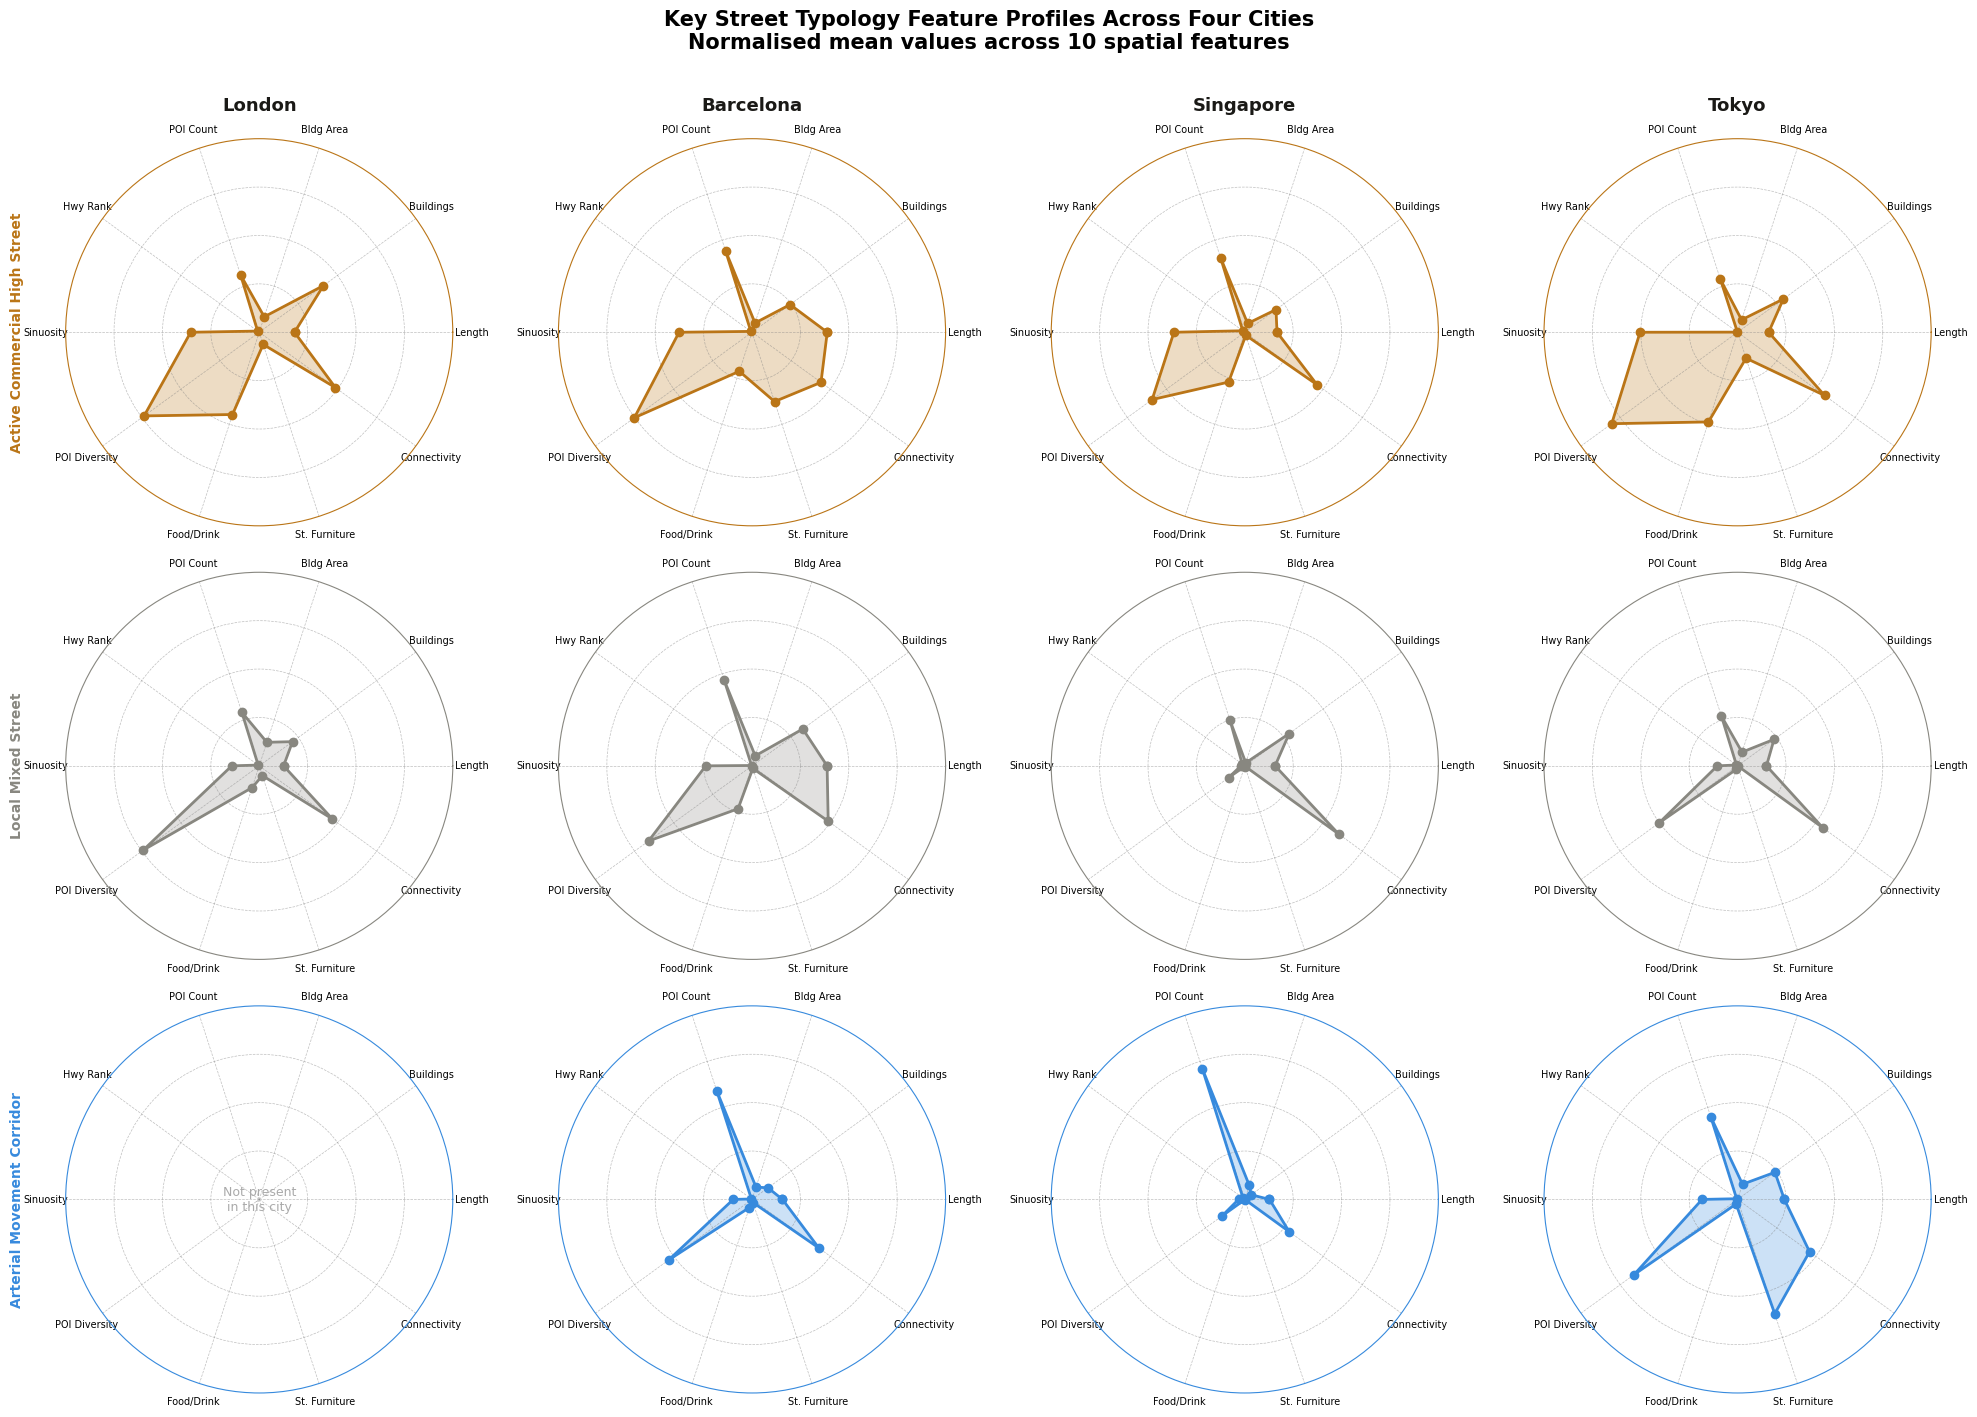

Figure 5.8 saved.


In [19]:
# Cross-city radar comparison — Figure 5.8
# Shows three key typologies across all four cities

key_typologies = [
    'Active Commercial High Street',
    'Local Mixed Street',
    'Arterial Movement Corridor'
]

city_names = ['London', 'Barcelona', 'Singapore', 'Tokyo']
city_dfs = {
    'London': london_clustered,
    'Barcelona': barcelona_clustered,
    'Singapore': singapore_clustered,
    'Tokyo': tokyo_clustered
}

fig, axes = plt.subplots(
    len(key_typologies), len(city_names),
    figsize=(20, 14),
    subplot_kw=dict(polar=True)
)

for row_idx, typology in enumerate(key_typologies):
    for col_idx, city_name in enumerate(city_names):
        ax = axes[row_idx][col_idx]
        city_df = city_dfs[city_name].copy()

        scaler_c = MinMaxScaler()
        city_df[FEATURE_COLS] = scaler_c.fit_transform(
            city_df[FEATURE_COLS].fillna(0))

        profiles = city_df.groupby('typology')[FEATURE_COLS].mean()
        colour = TYPOLOGY_COLOURS.get(typology, '#888780')

        if typology in profiles.index:
            values = profiles.loc[typology].values.tolist()
            values += values[:1]
            ax.plot(angles, values, 'o-', linewidth=2, color=colour)
            ax.fill(angles, values, alpha=0.25, color=colour)
        else:
            ax.text(0, 0, 'Not present\nin this city',
                   ha='center', va='center', fontsize=9,
                   color='#AAAAAA')

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(feature_labels_radar, size=7)
        ax.set_ylim(0, 1)
        ax.set_yticks([0.25, 0.5, 0.75])
        ax.set_yticklabels([])
        ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
        ax.spines['polar'].set_color(colour)

        if row_idx == 0:
            ax.set_title(city_name, size=13, fontweight='bold',
                        pad=20, color='#1A1916')
        if col_idx == 0:
            ax.set_ylabel(typology, size=10, fontweight='bold',
                         color=colour, labelpad=30)

fig.suptitle(
    'Key Street Typology Feature Profiles Across Four Cities\n'
    'Normalised mean values across 10 spatial features',
    fontsize=15, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig("/home/jovyan/work/outputs/radar_comparison.png",
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 5.8 saved.")

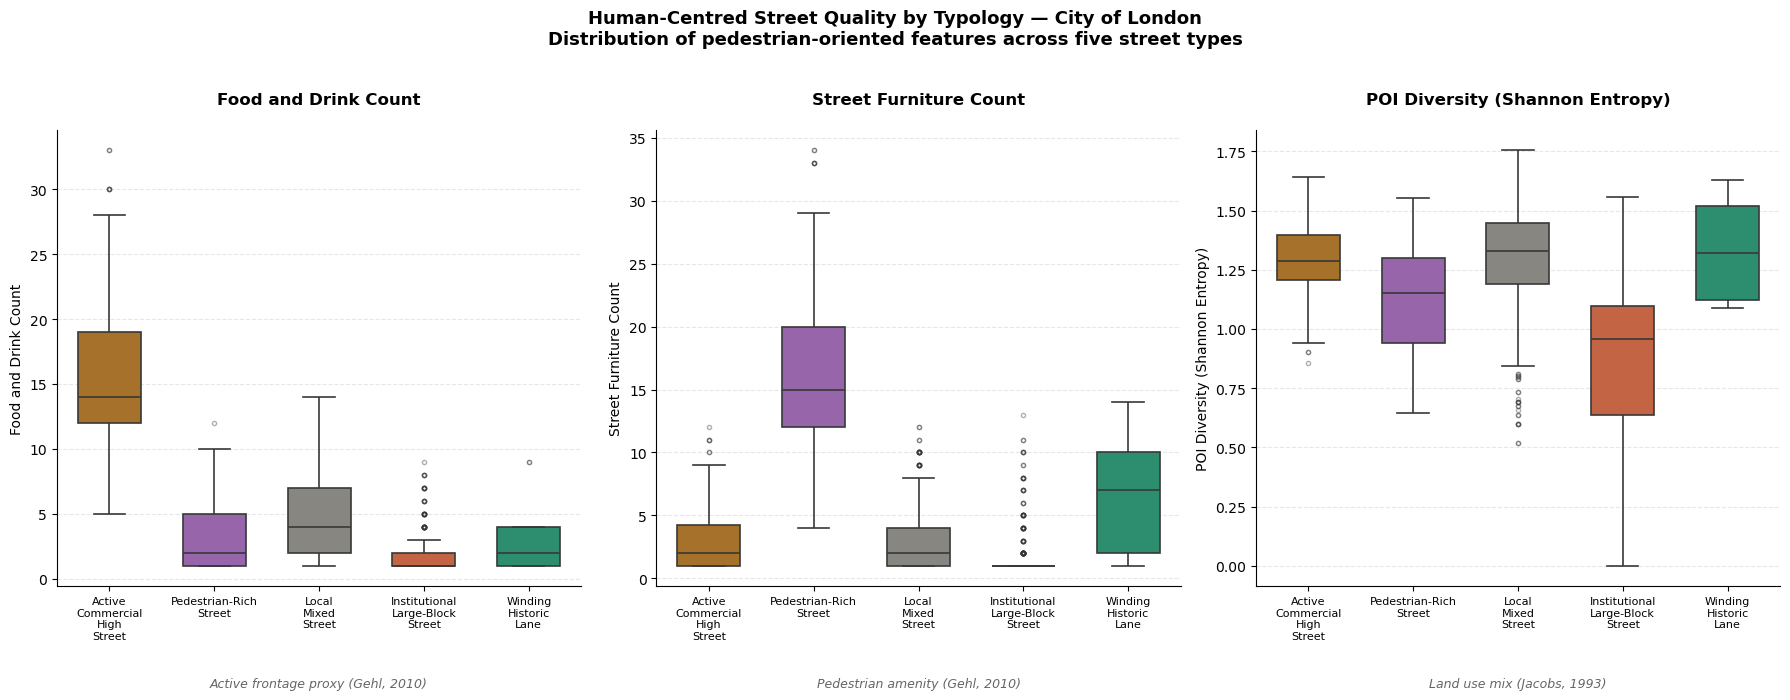

Figure 5.9 saved.


In [23]:
# Box plots — human-centred features by typology — London
# Directly answers RQ3 — Figure 5.9

typology_order = [
    'Active Commercial High Street',
    'Pedestrian-Rich Street',
    'Local Mixed Street',
    'Institutional Large-Block Street',
    'Winding Historic Lane'
]

plot_data = london_clustered[
    london_clustered['typology'].isin(typology_order)].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

human_features = [
    ('food_drink_count', 'Food and Drink Count',
     'Active frontage proxy (Gehl, 2010)'),
    ('street_furniture_count', 'Street Furniture Count',
     'Pedestrian amenity (Gehl, 2010)'),
    ('poi_diversity', 'POI Diversity (Shannon Entropy)',
     'Land use mix (Jacobs, 1993)')
]

palette = {t: TYPOLOGY_COLOURS.get(t, '#888780') for t in typology_order}

for idx, (feature, label, subtitle) in enumerate(human_features):
    ax = axes[idx]
    sns.boxplot(data=plot_data, x='typology', y=feature,
               order=typology_order, palette=palette, ax=ax,
               width=0.6, linewidth=1.2,
               flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(f'{label}\n', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(label, fontsize=10)
    ax.set_xticklabels(
        [t.replace(' ', '\n') for t in typology_order],
        fontsize=8, rotation=0)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.text(0.5, -0.22, subtitle, transform=ax.transAxes,
           ha='center', fontsize=9, style='italic', color='#666666')

fig.suptitle(
    'Human-Centred Street Quality by Typology — City of London\n'
    'Distribution of pedestrian-oriented features across five street types',
    fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig("/home/jovyan/work/outputs/boxplots_human_centred.png",
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 5.9 saved.")

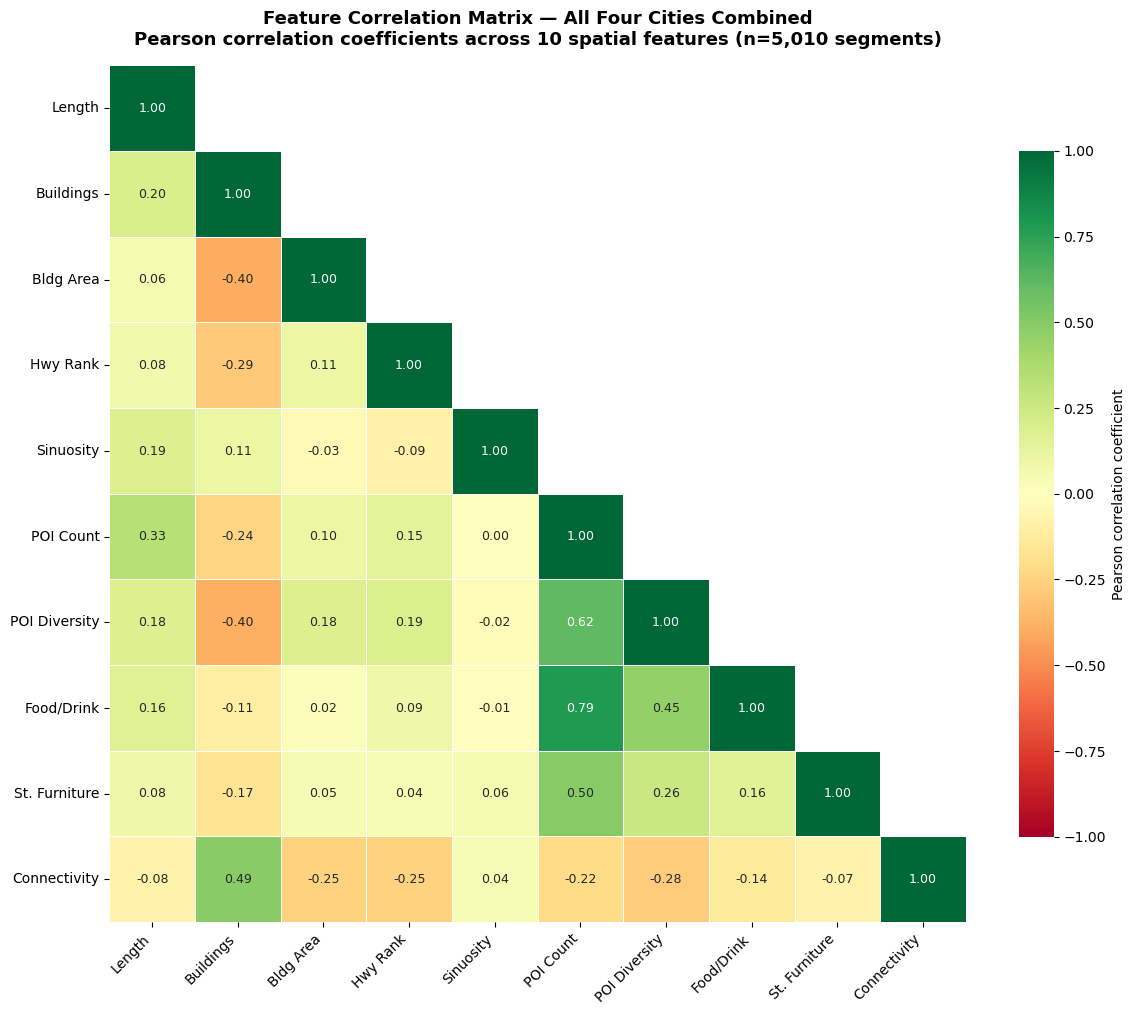

Figure 5.10 saved.


In [25]:
# Correlation heatmap — all four cities combined
# Figure 5.10

# Combine all four cities feature data
all_features_combined = pd.concat([
    london_clustered[FEATURE_COLS],
    barcelona_clustered[FEATURE_COLS],
    singapore_clustered[FEATURE_COLS],
    tokyo_clustered[FEATURE_COLS]
], ignore_index=True).fillna(0)

feature_labels_short = {
    'length_m': 'Length',
    'building_count_50m': 'Buildings',
    'avg_building_area': 'Bldg Area',
    'poi_count_50m': 'POI Count',
    'highway_rank': 'Hwy Rank',
    'sinuosity': 'Sinuosity',
    'poi_diversity': 'POI Diversity',
    'food_drink_count': 'Food/Drink',
    'street_furniture_count': 'St. Furniture',
    'avg_connectivity': 'Connectivity'
}

corr_data = all_features_combined.rename(columns=feature_labels_short)
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    ax=ax, square=True, linewidths=0.5, linecolor='white',
    annot_kws={'size': 9},
    cbar_kws={'shrink': 0.8, 'label': 'Pearson correlation coefficient'}
)

ax.set_title(
    'Feature Correlation Matrix — All Four Cities Combined\n'
    f'Pearson correlation coefficients across 10 spatial features (n=5,010 segments)',
    fontsize=13, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45,
                   ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig("/home/jovyan/work/outputs/correlation_heatmap.png",
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 5.10 saved.")

In [26]:
# Similarity search system
# Combines all four cities into one searchable database
# Returns real named streets similar to a design query
# Answers RQ2

from sklearn.neighbors import NearestNeighbors

# Combine all four cities — drop geometry for efficiency
london_ss = london_clustered[FEATURE_COLS + ['typology', 'city', 'name']].copy()
barcelona_ss = barcelona_clustered[FEATURE_COLS + ['typology', 'city', 'name']].copy()
singapore_ss = singapore_clustered[FEATURE_COLS + ['typology', 'city', 'name']].copy()
tokyo_ss = tokyo_clustered[FEATURE_COLS + ['typology', 'city', 'name']].copy()

all_streets_ss = pd.concat([
    london_ss, barcelona_ss, singapore_ss, tokyo_ss
], ignore_index=True)

all_streets_ss['name'] = all_streets_ss['name'].fillna('Unnamed Street')

def clean_name(name):
    s = str(name)
    if s.startswith('['):
        return s.strip("[]'\"").split("',")[0].strip("' ")
    return name

all_streets_ss['name'] = all_streets_ss['name'].apply(clean_name)

# Normalise and build KNN model
X_all = all_streets_ss[FEATURE_COLS].fillna(0).values
scaler_ss = StandardScaler()
X_all_scaled = scaler_ss.fit_transform(X_all)

knn = NearestNeighbors(n_neighbors=6, metric='cosine')
knn.fit(X_all_scaled)

print(f"Similarity search ready.")
print(f"Database: {len(all_streets_ss)} streets across 4 cities.")

Similarity search ready.
Database: 5010 streets across 4 cities.


In [34]:
# Query using actual streets from the database
# Find streets similar to a known Active Commercial High Street

def search_by_street(street_name, city_name, label):
    print(f"\n{'='*55}")
    print(f"Query: Streets similar to {street_name}, {city_name}")
    print(f"{'='*55}")
    
    # Find the query street in database
    mask = (all_streets_ss2['name'] == street_name) & \
           (all_streets_ss2['city'] == city_name)
    query_row = all_streets_ss2[mask]
    
    if len(query_row) == 0:
        print(f"Street not found")
        return
    
    query_idx = query_row.index[0]
    query_features = X_all_scaled2[query_idx].reshape(1, -1)
    
    distances, indices = knn2.kneighbors(query_features)
    
    results = []
    for i, idx in enumerate(indices[0][1:6]):
        row = all_streets_ss2.iloc[idx]
        similarity = round((1 - distances[0][i+1]) * 100, 1)
        results.append({
            'Rank': i + 1,
            'Street Name': row['name'],
            'City': row['city'],
            'Typology': row['typology'],
            'Similarity (%)': similarity
        })
    
    df = pd.DataFrame(results)
    print(df.to_string(index=False))
    return df

# Query using Cheapside — known Active Commercial High Street
r1 = search_by_street('Cheapside', 'London', 'Active Commercial High Street')

# Query using Bennet's Hill — known Winding Historic Lane  
r2 = search_by_street("Bennet's Hill", 'London', 'Winding Historic Lane')

# Query using Gran Via de les Corts Catalanes — known Arterial
r3 = search_by_street('Gran Via de les Corts Catalanes', 
                      'Barcelona', 'Arterial Movement Corridor')


Query: Streets similar to Cheapside, London
 Rank Street Name   City                      Typology  Similarity (%)
    1   Cheapside London Active Commercial High Street           100.0
    2   Cheapside London Active Commercial High Street            98.4
    3   Cheapside London Active Commercial High Street            98.4
    4 Wood Street London Active Commercial High Street            96.9
    5 Wood Street London Active Commercial High Street            96.9

Query: Streets similar to Bennet's Hill, London
 Rank   Street Name   City                         Typology  Similarity (%)
    1 Bennet's Hill London Institutional Large-Block Street           100.0
    2 Bennet's Hill London Institutional Large-Block Street            97.1
    3 Bennet's Hill London Institutional Large-Block Street            97.1
    4   Fore Street London Institutional Large-Block Street            95.3
    5   Fore Street London Institutional Large-Block Street            95.3

Query: Streets similar 

In [37]:
# Query using actual confirmed typology streets
r1 = search_by_street('Cheapside', 'London', 
                      'Active Commercial High Street')
r2 = search_by_street('West Smithfield', 'London', 
                      'Winding Historic Lane')
r3 = search_by_street('Gran Via de les Corts Catalanes', 
                      'Barcelona', 'Arterial Movement Corridor')


Query: Streets similar to Cheapside, London
 Rank Street Name   City                      Typology  Similarity (%)
    1   Cheapside London Active Commercial High Street           100.0
    2   Cheapside London Active Commercial High Street            98.4
    3   Cheapside London Active Commercial High Street            98.4
    4 Wood Street London Active Commercial High Street            96.9
    5 Wood Street London Active Commercial High Street            96.9

Query: Streets similar to West Smithfield, London
 Rank             Street Name      City                      Typology  Similarity (%)
    1         West Smithfield    London            Local Mixed Street            97.6
    2         West Smithfield    London        Pedestrian-Rich Street            96.0
    3 Carrer d'Enric Granados Barcelona Active Commercial High Street            95.8
    4         West Smithfield    London        Pedestrian-Rich Street            94.6
    5 Carrer de Floridablanca Barcelona Active C

In [41]:
# Final confirmed similarity search examples for dissertation

r1 = search_by_street('Cheapside', 'London',
                      'Active Commercial High Street')
r2 = search_by_street('Finsbury Circus', 'London',
                      'Winding Historic Lane')
r3 = search_by_street('Passeig de Gràcia', 'Barcelona',
                      'Arterial Movement Corridor')

r1.to_csv("/home/jovyan/work/data/similarity_example1_final.csv", index=False)
r2.to_csv("/home/jovyan/work/data/similarity_example2_final.csv", index=False)
r3.to_csv("/home/jovyan/work/data/similarity_example3_final.csv", index=False)

print("\nFinal similarity search examples saved.")
print("\nExample 1 — Active Commercial High Street:")
print(r1.to_string(index=False))
print("\nExample 2 — Winding Historic Lane:")
print(r2.to_string(index=False))
print("\nExample 3 — Arterial Movement Corridor:")
print(r3.to_string(index=False))


Query: Streets similar to Cheapside, London
 Rank Street Name   City                      Typology  Similarity (%)
    1   Cheapside London Active Commercial High Street           100.0
    2   Cheapside London Active Commercial High Street            98.4
    3   Cheapside London Active Commercial High Street            98.4
    4 Wood Street London Active Commercial High Street            96.9
    5 Wood Street London Active Commercial High Street            96.9

Query: Streets similar to Finsbury Circus, London
 Rank     Street Name   City              Typology  Similarity (%)
    1 West Smithfield London Winding Historic Lane            97.8
    2 Monkwell Square London Winding Historic Lane            97.0
    3 Monkwell Square London Winding Historic Lane            97.0
    4    Suffolk Lane London Winding Historic Lane            96.9
    5    Suffolk Lane London Winding Historic Lane            96.9

Query: Streets similar to Passeig de Gràcia, Barcelona
 Rank           Stre

In [39]:
# Try a different arterial street for example 3
# Check what Arterial Movement Corridor streets exist in Barcelona
barcelona_arterial = barcelona_clustered[
    barcelona_clustered['typology'] == 'Arterial Movement Corridor']
print("Barcelona Arterial Movement Corridor streets:")
print(barcelona_arterial[['name', 'highway_rank', 
                           'length_m', 'poi_count_50m']].head(10).to_string())

Barcelona Arterial Movement Corridor streets:
                               name  highway_rank    length_m  poi_count_50m
0                Plaça de Catalunya           4.0  153.937082             14
1                Plaça de Catalunya           4.0  212.724358              9
4                Plaça d'Urquinaona           4.0   69.134204             15
8                 Passeig de Gràcia           3.0   16.080588              4
9   Gran Via de les Corts Catalanes           5.0   20.799307              7
11               Plaça d'Urquinaona           4.0   63.098840             20
15              Carrer de Trafalgar           4.0   55.343117             12
20               Carrer de Muntaner           4.0   25.562565              8
23              Carrer de Viladomat           2.0   25.106729              8
26  Gran Via de les Corts Catalanes           5.0  180.343774             15


In [40]:
r3 = search_by_street('Passeig de Gràcia', 'Barcelona',
                      'Arterial Movement Corridor')
print("\nChecking Passeig de Gràcia typology:")
print(barcelona_clustered[barcelona_clustered['name'] == 'Passeig de Gràcia'][
    ['name', 'typology', 'highway_rank', 'length_m', 'sinuosity']].to_string())


Query: Streets similar to Passeig de Gràcia, Barcelona
 Rank           Street Name      City                   Typology  Similarity (%)
    1 Plaça del Cinc d'Oros Barcelona Arterial Movement Corridor            99.0
    2     Passeig de Gràcia Barcelona Arterial Movement Corridor            98.9
    3     Passeig de Gràcia Barcelona Arterial Movement Corridor            98.3
    4     Passeig de Gràcia Barcelona Arterial Movement Corridor            98.3
    5     Passeig de Gràcia Barcelona Arterial Movement Corridor            97.2

Checking Passeig de Gràcia typology:
                   name                       typology  highway_rank    length_m  sinuosity
8     Passeig de Gràcia     Arterial Movement Corridor           3.0   16.080588   1.007657
185   Passeig de Gràcia             Local Mixed Street           3.0  179.954644   1.000000
187   Passeig de Gràcia             Local Mixed Street           3.0  179.611129   1.000015
217   Passeig de Gràcia             Local Mixed Stre

In [42]:
# Interactive similarity search widget
# Select a known street and find similar streets globally

import ipywidgets as widgets
from IPython.display import display, clear_output

known_streets = {
    'Cheapside, London (Active Commercial High Street)': 
        ('Cheapside', 'London'),
    'Finsbury Circus, London (Winding Historic Lane)': 
        ('Finsbury Circus', 'London'),
    'Passeig de Gràcia, Barcelona (Arterial Movement Corridor)': 
        ('Passeig de Gràcia', 'Barcelona'),
    'Wood Street, London (Active Commercial High Street)': 
        ('Wood Street', 'London'),
    'Monkwell Square, London (Winding Historic Lane)': 
        ('Monkwell Square', 'London'),
}

dropdown = widgets.Dropdown(
    options=list(known_streets.keys()),
    description='Query street:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='500px')
)

button = widgets.Button(
    description='Find Similar Streets',
    button_style='primary',
    layout=widgets.Layout(width='200px')
)

output = widgets.Output()

def run_search(b):
    with output:
        clear_output()
        selected = dropdown.value
        street_name, city_name = known_streets[selected]
        
        mask = (all_streets_ss2['name'] == street_name) & \
               (all_streets_ss2['city'] == city_name)
        query_row = all_streets_ss2[mask]
        
        if len(query_row) == 0:
            print("Street not found")
            return
        
        query_idx = query_row.index[0]
        query_features = X_all_scaled2[query_idx].reshape(1, -1)
        distances, indices = knn2.kneighbors(query_features)
        
        results = []
        for i, idx in enumerate(indices[0][1:6]):
            row = all_streets_ss2.iloc[idx]
            similarity = round((1 - distances[0][i+1]) * 100, 1)
            results.append({
                'Rank': i + 1,
                'Street Name': row['name'],
                'City': row['city'],
                'Typology': row['typology'],
                'Similarity (%)': similarity
            })
        
        print(f"Streets similar to: {street_name}, {city_name}")
        print("-" * 55)
        display(pd.DataFrame(results))

button.on_click(run_search)

print("Street Typology Explorer")
print("Select a street and click Find Similar Streets")
display(dropdown)
display(button)
display(output)

Street Typology Explorer
Select a street and click Find Similar Streets


Dropdown(description='Query street:', layout=Layout(width='500px'), options=('Cheapside, London (Active Commer…

Button(button_style='primary', description='Find Similar Streets', layout=Layout(width='200px'), style=ButtonS…

Output()

In [43]:
# cluster profiles across all cities
all_combined = pd.concat([
    london_clustered[FEATURE_COLS + ['typology']],
    barcelona_clustered[FEATURE_COLS + ['typology']],
    singapore_clustered[FEATURE_COLS + ['typology']],
    tokyo_clustered[FEATURE_COLS + ['typology']]
], ignore_index=True).fillna(0)

table_51 = all_combined.groupby('typology').agg(
    n=('typology', 'count'),
    length_m=('length_m', 'mean'),
    poi_count=('poi_count_50m', 'mean'),
    food_drink=('food_drink_count', 'mean'),
    bldg_area=('avg_building_area', 'mean'),
    hwy_rank=('highway_rank', 'mean'),
    sinuosity=('sinuosity', 'mean'),
    st_furniture=('street_furniture_count', 'mean')
).round(2)

print("Table 5.1 — Street Typology Profiles:")
print(table_51.to_string())

table_51.to_csv("/home/jovyan/work/data/table_51_typology_profiles.csv")
print("\nSaved.")

Table 5.1 — Street Typology Profiles:
                                     n  length_m  poi_count  food_drink  bldg_area  hwy_rank  sinuosity  st_furniture
typology                                                                                                             
Active Boulevard                    14    330.37      37.21        9.57    1089.85      1.86       1.50          4.79
Active Commercial High Street      473    108.17      30.89       10.26     838.46      2.62       1.03          4.05
Arterial Movement Corridor         800     72.88       7.68        1.70    1379.78      3.47       1.01          1.30
Dense Local Street                 964     72.37       1.85        1.00     121.51      1.91       1.02          1.00
Institutional Large-Block Street   420     50.45       7.53        1.92    4022.69      2.61       1.01          1.74
Local Mixed Street                2208    101.62      13.22        3.83     849.94      2.50       1.02          1.66
Pedestrian-Rich St